# **What Does This Dataset Represent?**
The dataset represent land information in saudi Arabia.
Here is the data description:


## **Columns Description**
*   mainlocation:	The main location of the land.
*   sublocation: Indicates the subregion of the location.
*   neighborhood: The neighborhood where the land resides.
*   frontage: The cardinal direction where the land faces the street.
*   purpose: The purpose for land use.
*   streetwidth: The length of the street facing the land in meters.
*   size: The size of the land in meters squared.
*   Pricepm: The price per meters squared.

## **Define the Problem**
*   Regression Problem
*   the target is calculate land price with the foolowing equasion: (price per meters squared) * (size in meters squared).
*   Leakage features: size, Pricepm




# Import Libaries

In [1]:
!pip install arabic-reshaper python-bidi

In [2]:
import warnings
# Suppress all warnings
warnings.filterwarnings('ignore')
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
np.set_printoptions(suppress=True)
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import Ridge

import arabic_reshaper
from bidi.algorithm import get_display


# Start on Explore the data set.

## Read the data set.

In [3]:
path = kagglehub.dataset_download("hussainalqatari/land-market-in-saudi-arabia")

print("Path to dataset files:", path)

dataset = pd.read_csv(path + "/aqardata_2.csv")

Using Colab cache for faster access to the 'land-market-in-saudi-arabia' dataset.
Path to dataset files: /kaggle/input/land-market-in-saudi-arabia


In [4]:
print(dataset.shape)
display(dataset.head(n=20))

(2951, 8)


,mainlocation,sublocation,neighborhood,frontage,purpose,streetwidth,size,Pricepm
0,الرياض,غرب الرياض,حي ظهرة لبن,شمال,سكني,20.0,727,1800
1,بريدة,NaN,حي مشعل,غرب,NaN,15.0,450,950
2,الخبر,NaN,حي الحمرا,غرب,تجاري,100.0,1450,3500
3,الخبر,NaN,حي الحزام الاخضر,شرق,NaN,15.0,440,2700
4,بريدة,NaN,حي الرحاب,جنوب غربي,NaN,40.0,784,950
5,الرياض,شمال الرياض,حي العارض,جنوب,تجاري,60.0,5973,2000
6,جدة,شمال جدة,حي الريان,شرق,سكني,20.0,660,2300
7,سكاكا,NaN,حي مخطط كريم الدرزي,شمال,سكني,15.0,735,219
8,الجموم,NaN,حي النسيم,غرب,NaN,60.0,153500,195
9,المدينة المنورة,NaN,حي الخالدية,شمال غربي,تجاري,40.0,591,5076


In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2951 entries, 0 to 2950
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mainlocation  2951 non-null   object 
 1   sublocation   2276 non-null   object 
 2   neighborhood  2951 non-null   object 
 3   frontage      2951 non-null   object 
 4   purpose       2604 non-null   object 
 5   streetwidth   2948 non-null   float64
 6   size          2951 non-null   int64  
 7   Pricepm       2951 non-null   int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 184.6+ KB


## Processing the data set.

In [6]:
print(dataset.duplicated().sum())

1


In [7]:
dataset = dataset.drop_duplicates()
print(dataset.duplicated().sum())

0


In [8]:
print(dataset.isnull().sum())

mainlocation      0
sublocation     675
neighborhood      0
frontage          0
purpose         347
streetwidth       2
size              0
Pricepm           0
dtype: int64


*    sublocation has many nulls so i desided to drop it.
*   nulls in streetwidth is only 2 values so i will delete it.


*   for purpose i will see how can i handle it

In [9]:
dataset = dataset.drop('sublocation', axis = 1)
dataset.dropna(subset=['streetwidth'], inplace=True)
print(dataset.shape)
display(dataset.head(n=20))

(2948, 7)


,mainlocation,neighborhood,frontage,purpose,streetwidth,size,Pricepm
0,الرياض,حي ظهرة لبن,شمال,سكني,20.0,727,1800
1,بريدة,حي مشعل,غرب,NaN,15.0,450,950
2,الخبر,حي الحمرا,غرب,تجاري,100.0,1450,3500
3,الخبر,حي الحزام الاخضر,شرق,NaN,15.0,440,2700
4,بريدة,حي الرحاب,جنوب غربي,NaN,40.0,784,950
5,الرياض,حي العارض,جنوب,تجاري,60.0,5973,2000
6,جدة,حي الريان,شرق,سكني,20.0,660,2300
7,سكاكا,حي مخطط كريم الدرزي,شمال,سكني,15.0,735,219
8,الجموم,حي النسيم,غرب,NaN,60.0,153500,195
9,المدينة المنورة,حي الخالدية,شمال غربي,تجاري,40.0,591,5076


In [10]:
print(dataset.isnull().sum())

mainlocation      0
neighborhood      0
frontage          0
purpose         347
streetwidth       0
size              0
Pricepm           0
dtype: int64


*   Now try to handel purpose colmun.
*   purpose is obj column.



## handle purpose column by using streetwidth values.

In [11]:
def arabic_text(text):
    reshaped = arabic_reshaper.reshape(text)
    return get_display(reshaped)

In [12]:
print(dataset['streetwidth'].mean())
print(dataset['streetwidth'].median())

24.691994572591586
20.0


In [13]:
dataset_copy = dataset.copy()

#dataset_copy['purpose_display'] = dataset_copy['purpose'].fillna('').astype(str).apply(arabic_text)
dataset_copy['purpose_display'] = dataset_copy['purpose'].apply(
    lambda x: arabic_text(x) if pd.notna(x) else x
)

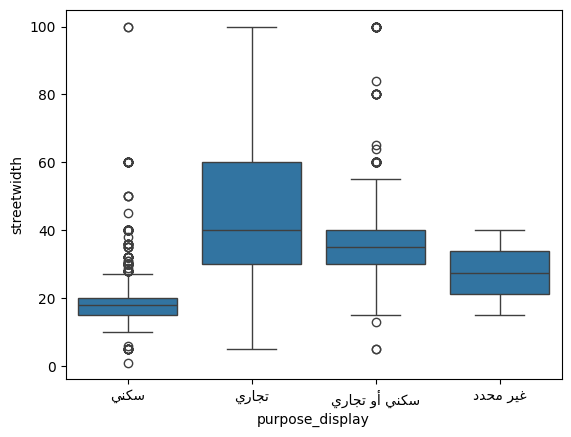

In [14]:
#streetwidth
sns.boxplot(x='purpose_display', y='streetwidth', data=dataset_copy)
plt.show()

In [15]:
dataset['streetwidth'].mean()

np.float64(24.691994572591586)

In [16]:
streetwidth_groupby_purpose = dataset.groupby('purpose')['streetwidth'].mean()
streetwidth_groupby_purpose

,streetwidth
purpose,
تجاري,45.734756
سكني,19.231653
سكني أو تجاري,40.802239
غير محدد,27.500000


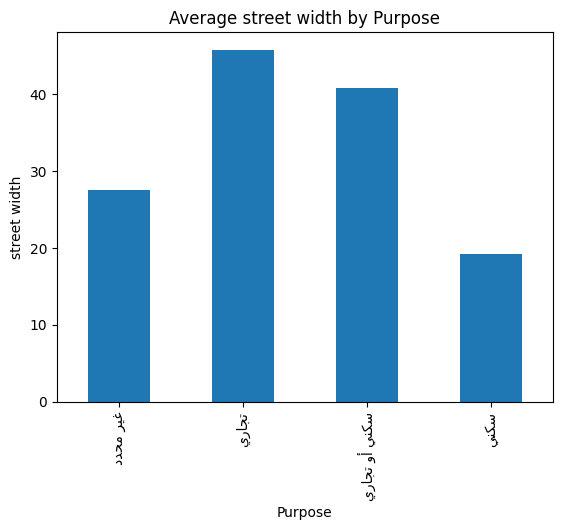

In [17]:
dataset_copy.groupby('purpose_display')['streetwidth'].mean().plot(kind='bar')

plt.xlabel("Purpose")
plt.ylabel("street width")
plt.title("Average street width by Purpose")
plt.show()

####**Final desecion**

Based on statistical analysis and data visualization, it has been concluded that **`streetwidth`** is the most reliable predictor for understanding and imputing missing values in the `purpose` column. The findings are summarized as follows:

**1. Street Width: The Most Decisive Factor**

* The analysis reveals a clear and significant gap in the average street width between residential and commercial properties.
* The average street width for **Commercial** land is approximately **45.7m**, whereas for **Residential** land, it is about **19.2m**.
* This distinct numerical separation makes `streetwidth` an excellent threshold for classifying land use with high confidence.

 **2. Land Size: An Inconclusive Relationship**

* Contrary to initial assumptions, land size did not exhibit a strong correlation or a consistent pattern with the property's purpose.
* Both large residential plots and relatively small commercial plots exist in the dataset, making "Size" an unreliable standalone metric for imputation.

**3. Price per Meter (Pricepm): Geographical Interference**

* The price per square meter is heavily influenced by the **prestige of the neighborhood** and the city rather than the purpose alone.
* **The Challenge:** A residential plot in a high-end district (e.g., in Riyadh) can be significantly more expensive than a commercial plot in a smaller city. This overlap makes `Pricepm` a misleading indicator for determining the purpose.

**4. Location, Neighborhood, and Frontage: Secondary Indicators**

* Features such as `mainlocation`, `neighborhood`, and `frontage` provided mixed results.
* While certain cities show a high density of residential plots, these columns contain high variance and overlapping values, preventing them from being used as a primary standard for classification.

---

**Conclusion:**

The **`streetwidth`** feature will be adopted as the primary logic for handling missing values in the `purpose` column, supplemented by location-based averages to ensure maximum prediction accuracy.


*   mean streetwidth : ~24.7
*   mean streetwidth when purpose = commerical: ~45.7
*   mean streetwidth when purpose = residential: ~19.2
*   mean streetwidth when purpose = residential or commerical: ~40.8



*   if streetwidth < mean_residential then i will fill null with 'سكني'.
*   if streetwidth > mean_commerical then i will fill null with 'تجاري'
*   if  mean_residential > streetwidth < mean_commerical then i will fill null with 'سكني أو تجاري''

In [18]:
mean_commerical = dataset[dataset["purpose"] == "تجاري"]['streetwidth'].mean()
mean_sakani = dataset[dataset["purpose"] == "سكني"]['streetwidth'].mean()
dataset.loc[(dataset['purpose'].isna()) & (dataset['streetwidth'] < mean_sakani), 'purpose'] = 'سكني'
dataset.loc[(dataset['purpose'].isna()) & (dataset['streetwidth'] > mean_commerical), 'purpose'] = 'تجاري'
dataset.loc[(dataset['purpose'].isna()) , 'purpose'] = 'سكني أو تجاري'

In [19]:
dataset.isnull().sum()

,0
mainlocation,0
neighborhood,0
frontage,0
purpose,0
streetwidth,0
size,0
Pricepm,0


# Machine Learning part

## Split the data
i will use train_test_split.

In [20]:
dataset['land_price'] = dataset['Pricepm']*dataset['size'] #calculate land price, the target
X = dataset.drop(['Pricepm','land_price'], axis=1)
print(X.columns)
y = dataset['land_price']

Index(['mainlocation', 'neighborhood', 'frontage', 'purpose', 'streetwidth',
       'size'],
      dtype='object')


## train test split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

y_train = np.log(y_train)
y_test = np.log(y_test)

###one_hot_encoding and log normalize

In [22]:
#one_hot_encoding
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()
X_train_encoded['streetwidth'] = np.log(X_train_encoded['streetwidth'])
X_test_encoded['streetwidth'] = np.log(X_test_encoded['streetwidth'])
X_train_encoded['size'] = np.log(X_train_encoded['size'])
X_test_encoded['size'] = np.log(X_test_encoded['size'])

X_train_encoded = pd.get_dummies(X_train_encoded)
X_test_encoded = pd.get_dummies(X_test_encoded)

X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

MAE =  0.25060553198219154
RMSE = 0.41571016885101125
R^2 = 0.9055436479502432


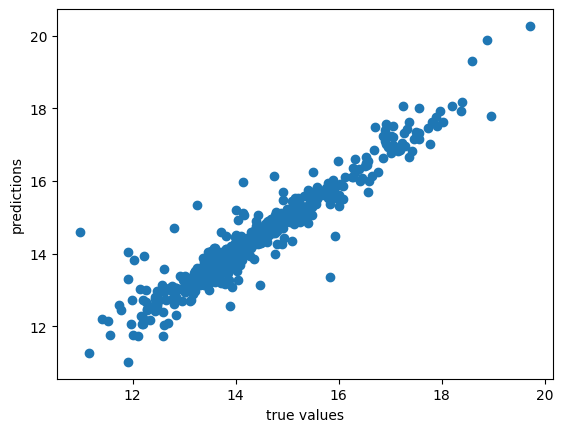

In [ ]:
y_pred=0
#Evaluation the models
model = Ridge()
model.fit(X_train_encoded, y_train)  # Train the model
y_pred = model.predict(X_test_encoded)  # Predict the test set
MAE = mean_absolute_error(y_test, y_pred)
RMSE = np.sqrt(mean_squared_error(y_test, y_pred))
R2 = r2_score(y_test, y_pred)
print(f"MAE =  {MAE}")
print(f"RMSE = {RMSE}")
print(f"R^2 = {R2}")
plt.plot(y_test, y_pred, 'o')
plt.xlabel('true values')
plt.ylabel('predictions')
plt.show()


In [24]:
dataset.to_csv("dataset_clean.csv", index=False, encoding="utf-8-sig")

In [25]:
type(y_pred)

numpy.ndarray

In [25]:
#save the model
import joblib

joblib.dump(model, 'land_price_model.pkl')

['land_price_model.pkl']